<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Week4/Week_4_Assignment_Nikolai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Logistic Regression: R → Python Bridge**

## **Nikolai Navarro**

---

## Learning Objectives
By the end of this assignment, you should be able to:

- Fit and interpret logistic regression models
- Translate workflows from R (glm / tidymodels) to Python
- Interpret odds ratios
- Evaluate classification models using Accuracy and ROC–AUC
- Reflect on the difference between statistical inference vs prediction

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")
df

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily
...,...,...,...,...,...,...
595,100596,232811.0,1443.241197,3.0,Midtown,Condo
596,100597,235624.0,1083.909714,2.0,Suburb,Condo
597,100598,244889.0,1600.126432,1.0,Suburb,SingleFamily
598,100599,239545.0,1248.216637,1.0,Waterfront,Condo


---
## Part E - Explore the Dataset
Before modeling, briefly explore the data.

Create at least three plots such as:

- Histogram of price
- Scatter plot: size vs price
- Boxplot: price by neighborhood
- Bar chart: housing type

Text(0, 0.5, '# of Houses')

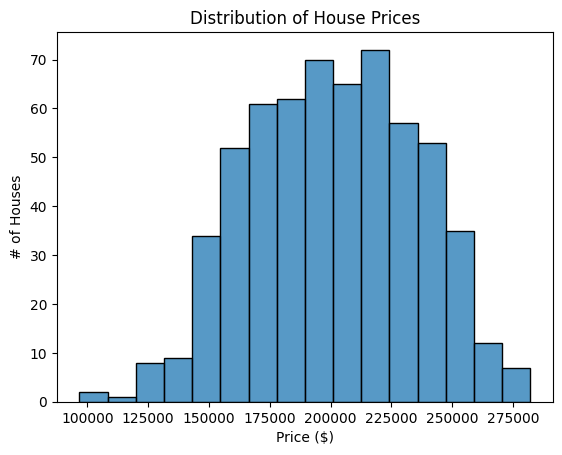

In [32]:
sns.histplot(data= df, x= "price")
plt.title("Distribution of House Prices")
plt.xlabel("Price ($)")
plt.ylabel("# of Houses")

Text(0, 0.5, 'Price ($)')

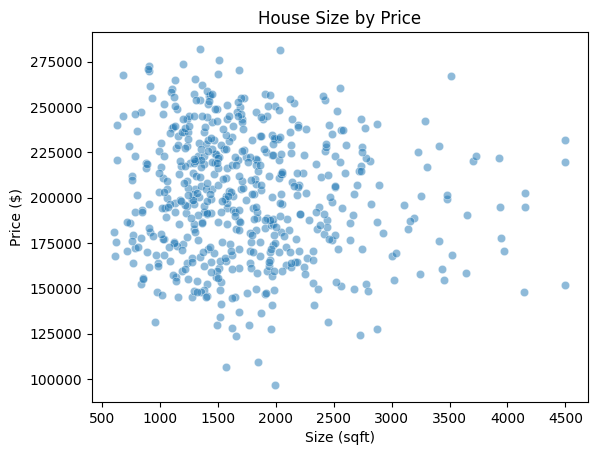

In [37]:
sns.scatterplot(data= df, x= "size", y= "price", alpha= 0.5)
plt.title("House Size by Price")
plt.xlabel("Size (sqft)")
plt.ylabel("Price ($)")

Text(0, 0.5, 'Price ($)')

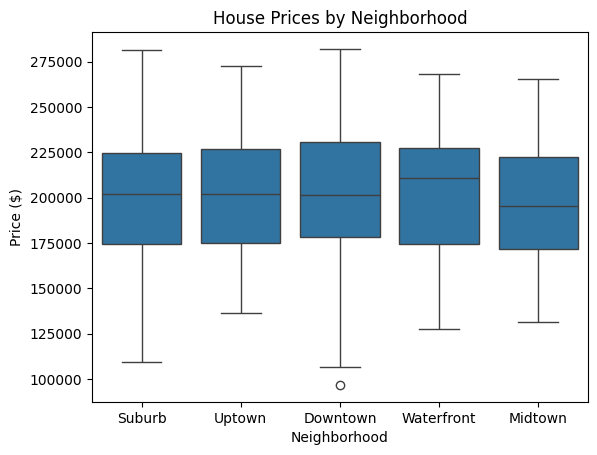

In [40]:
sns.boxplot(data=df, x="neighborhood", y="price")
plt.title("House Prices by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Price ($)")

Discuss one interesting pattern you observe.

looking at the boxplots one interesting pattern I see is that 4 of the 5 neighborhoods (excluding waterfront) have similar median house prices around 200,000. The histogram allso shows most of the house prices gathering around  between 185,000 to 215,000 which correlates with the boxplots showing us similar medians.

---

## Step 0 - Create a Binary Outcome
For classification, convert price into a binary variable.

```
high_price = price > median(price)
```
This creates two groups:

- `1` → expensive homes
- `0` → less expensive homes

In [5]:
df["high_price"] = (df["price"] > df["price"].median()).astype(int)
df

,listing_id,price,size,bedrooms,neighborhood,type,high_price
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse,0
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily,0
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily,0
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily,0
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily,0
...,...,...,...,...,...,...,...
595,100596,232811.0,1443.241197,3.0,Midtown,Condo,1
596,100597,235624.0,1083.909714,2.0,Suburb,Condo,1
597,100598,244889.0,1600.126432,1.0,Suburb,SingleFamily,1
598,100599,239545.0,1248.216637,1.0,Waterfront,Condo,1


---
## Part A - Logistic Regression for Inference

In Python

Fit the equivalent model using statsmodels.

Example:
```
import statsmodels.formula.api as smf

model = smf.logit(
    "high_price ~ size + bedrooms + C(neighborhood)",
    data=df
).fit()

print(model.summary())
```

Report

Create a table including:

- coefficients
- odds ratios
- p-values

Odds ratios:
```
odds_ratio = exp(coefficient)
```

In [6]:
model = smf.logit(
    "high_price ~ size + bedrooms + C(neighborhood) + C(type)", data=df
).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.683349
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                  524
Model:                          Logit   Df Residuals:                      514
Method:                           MLE   Df Model:                            9
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                 0.01414
Time:                        00:59:51   Log-Likelihood:                -358.07
converged:                       True   LL-Null:                       -363.21
Covariance Type:            nonrobust   LLR p-value:                    0.3292
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.2590      0.309      0.837      0.

In [7]:
coef = model.params
odds_ratio = np.exp(coef)
p_value = model.pvalues
pd.DataFrame({"Coefficient": coef, "Odds ratio": odds_ratio, "P value": p_value})

,Coefficient,Odds ratio,P value
Intercept,0.259034,1.295677,0.402535
C(neighborhood)[T.Midtown],-0.265734,0.766643,0.352048
C(neighborhood)[T.Suburb],0.140164,1.150462,0.586668
C(neighborhood)[T.Uptown],0.055166,1.056716,0.842292
C(neighborhood)[T.Waterfront],0.432651,1.541338,0.223709
C(type)[T.MultiFamily],0.007946,1.007977,0.980126
C(type)[T.SingleFamily],0.116854,1.123955,0.603092
C(type)[T.Townhouse],0.320389,1.377664,0.213238
size,-0.000525,0.999475,0.036582
bedrooms,0.230827,1.259642,0.085279


Answer:

- Which predictors appear statistically significant?
- Which neighborhood has higher odds of expensive homes?

The only predictor that seems statistically significant is size because its p-value is less than 0.05 at 0.03 while the other predictors have p-values greater than 0.05.  The waterfront neighborhood has the highest odds of expensive homes as its odds ratio is 1.54 which is the highest.

---

##Part B - Interpretation (Plain Language)
Choose one variable and explain its odds ratio.

Example:

“For every additional bedroom, the odds of a house being expensive increase by ___.”

Your explanation should be understandable to someone without statistics training.

When an odd ratio is greater than 1 then there is increased odds of an event occuring in this case being the house being a high price. When it is less than 1 the odds are decreased instead. Looking at the bedrooms variable we see the odds ratio is 1.26. So for every additional bedroom in a house the odds of the house being high price increases by 26%.

---

## Part C - Prediction Workflow

1. Train/Test Split

Split the data:

- 80% training
- 20% testing

In [17]:
df = df.dropna()
X = df[["size", "bedrooms", "neighborhood", "type"]]
y = df["high_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

2. Fit Logistic Regression

In [18]:
model_sk = LogisticRegression(max_iter=1000)
model_sk.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

3. Evaluate the Model ( check slides for more info about this)

Report:

- Accuracy
- ROC-AUC

In [29]:
y_pred = model_sk.predict(X_test)
y_prob = model_sk.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print("accuracy:", accuracy)
print("roc_auc:", roc_auc)

accuracy: 0.4666666666666667
roc_auc: 0.43936092955700795


---
## Part D - Model Understanding
Accuracy vs AUC

Why might ROC-AUC sometimes be preferred over accuracy?

Roc-auc considers all possible thresholds compared to accuracy which considers one threshold (typically 0.5). This means that roc-auc can give you a more realistic and complete model performance compared to accuracy.

Inference vs Prediction

Which modeling approach would you choose for:

- Policy analysis
- Prediction tasks

For policy analysis I would choose statsmodel because it allows us to see the relationship between variables and gives us information such as the coefficient, p-value, and confidence intervals.
For prediction tasks I would use scikit-learn because it is designed more for predicting data and evaluating model performance.